In [1]:
# basic imports and setting JAX options
import numpy as np
import jax
from matplotlib import pyplot as plt
from model_augmentation_jax import LinearTimeInvariantSystem, StaticLFRAugmentation
from model_augmentation_jax.utils import NRMSE_loss, compute_normalization_constants


jax.config.update('jax_platform_name', 'cpu')
if not jax.config.jax_enable_x64:
    jax.config.update("jax_enable_x64", True)  # Enable 64-bit computations

Throughout the examples we will use dummy data-generating systems and baseline models. For phyics-inspired examples, see the more advanced applications insided the specific folders.

In [2]:
# Generate or load data
np.random.seed(0)
U = np.random.normal(size=10_000) # Input sequence
x = [0, 0] # Initial state
ylist = [] # Output sequence
for uk in U:
    ylist.append(x[0] + np.random.normal(loc=0., scale=0.01))  # Compute output
    x = 0.9 * x[0] + 0.1 * x[1] + 0.1 * uk + 0.02 * x[0] * x[1], \
       -0.2 * x[0] + 0.95 * x[1] + 0.05 * uk - 0.1 * x[0]**3 # Advance state

# Split dataset
Y = np.array(ylist)
Y_train = Y[:9000]
Y_test = Y[9000:]
U_train = U[:9000]
U_test = U[9000:]

As a first example, we will use a simple discrete-time LTI model as the baseline component. Note that for these type of systems, the baseline model co-estimation is not enabled. Jointly tuning baseline model parameters and learning component parameters requires implementing the LTI system dynamics as a general nonlinear system (see example 1).

In [3]:
# create LTI baseline model (with approximate params)
A_mx = np.array([[0.88, 0.11], [-0.2, 0.94]])
B_mx = np.array([[0.1], [0.]])
C_mx = np.array([[1., 0.]])
fp_model = LinearTimeInvariantSystem(A=A_mx, B=B_mx, C=C_mx)

Next, we create the normalization constants (means and standard deviations of each signal). However, as we have no available state information, only input-output data, the baseline model is forward simulated on the training data set and the generate state trajectories are used for normalization.

In [ ]:
# simulate baseline model to approximate constants for normalization
Yhat_train_base, Xhat_train_base = fp_model.simulate(U_train)  # starts from x0 = 0
norm = compute_normalization_constants(U_train, Y_train, Xhat_train_base)

Next, we create a simple, static with the $D_\mathrm{zw}=0$ constraint. For lower-triangular feedback matrix, see example 1. For more advanced structures, see example 2. We train the models for a reasonable amount of iterations, which can be set by using the `set_optimization_parameters` method of the model, then training is started with the `fit` method. As visible, this simpler structure with relatively few training samples is trained rapidly.

In [ ]:
# create augmented model
model = StaticLFRAugmentation(known_sys=fp_model, hidden_layers=2, nodes_per_layer=8, activation="tanh", nz=2, nw=2,
                              norm_dict=norm)

# set training options
model.set_optimization_parameters(adam_epochs=100, lbfgs_epochs=500, train_x0=True, verbosity=50)

# train the model
model.fit(Y_train, U_train)

In [6]:
print(f"Model training finished in {model.t_solve} seconds.")

Model training finished in 4.239250421524048 seconds.


Before testing the model, we need to estimate the initial states corresponding to the test trajectory. We can achieve this by using a state initialization window, i.e., the first $n$ number of input-output data points of the test set, and then call the `learn_x0` method of the model.

In [7]:
# estimate initial state based on first 10 samples of the test data
x0_test = model.learn_x0(U_test[:10], Y_test[:10], verbosity=False)

Now we can simulate the model on the test data and evaluate its performance.

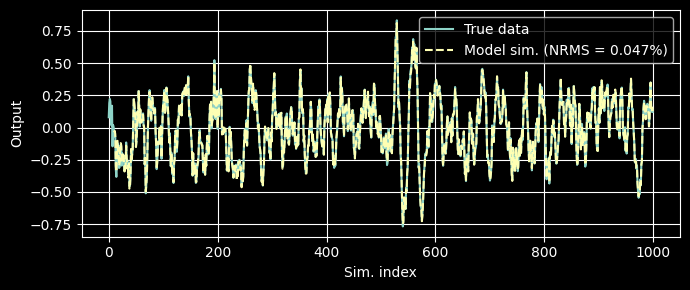

In [8]:
# simulate model
Yhat_test, _ = model.simulate(U_test, X0=x0_test)

nrmse = NRMSE_loss(Yhat_test[10:], Y_test[10:])  # only consider the part that was not used in state estimation

# visualize model output
sim_idx = np.arange(U_test.shape[0])
plt.figure(figsize=(7,3), layout="tight")
plt.plot(sim_idx, Y_test, label="True data")
plt.plot(sim_idx[10:], Yhat_test[10:], '--', label=f"Model sim. (NRMS = {nrmse:.2}%)")
plt.legend()
plt.grid()
plt.xlabel("Sim. index")
plt.ylabel("Output")
plt.show()